In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import os
import scipy
import shutil
import numpy as np
import pandas as pd
from PIL import Image
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
import torchvision.transforms as T
from tensorflow import keras, cast
from tensorflow.data import AUTOTUNE
from os import listdir, path , makedirs
from torchvision.datasets import ImageFolder
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import Model, backend as K
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import DenseNet121, InceptionV3
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.metrics import Accuracy, Precision, Recall
from sklearn.metrics import classification_report,confusion_matrix
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import load_img, img_to_array, save_img , ImageDataGenerator
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Activation, BatchNormalization, Input , GlobalAveragePooling2D


from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Input
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.metrics import Precision, Recall

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import CategoricalCrossentropy


In [30]:

# Training parameters
batch_size = 45
img_height = 224
img_width = 224
epochs = 200
epsilon = 0.1

dataset_dir = '/content/drive/My Drive/garbage dataset'
base_train_dir = '/content/drive/My Drive/split garbage dataset/train'
base_val_dir = '/content/drive/My Drive/split garbage dataset/validation'
base_test_dir = '/content/drive/My Drive/split garbage dataset/test'


# os.makedirs(base_train_dir, exist_ok=True)
# os.makedirs(base_val_dir, exist_ok=True)
# os.makedirs(base_test_dir, exist_ok=True)

# for class_name in os.listdir(dataset_dir):
#     os.makedirs(os.path.join(base_train_dir, class_name), exist_ok=True)
#     os.makedirs(os.path.join(base_val_dir, class_name), exist_ok=True)
#     os.makedirs(os.path.join(base_test_dir, class_name), exist_ok=True)



In [ ]:
# def copy_split_data(images, labels, train_dir, val_dir, test_dir, val_size=0.2, test_size=0.2):
#     # First split the dataset into training and temp (validation + test) sets
#     X_train, X_temp, y_train, y_temp = train_test_split(images, labels, test_size=(val_size + test_size), random_state=42)

#     # Now split the temp set into validation and test sets
#     val_test_split = test_size / (val_size + test_size)  # Adjust test size proportionally
#     X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=val_test_split, random_state=42)



#     # Copy training files
#     for img_path, label in zip(X_train, y_train):
#         shutil.copy(img_path, os.path.join(train_dir, label, os.path.basename(img_path)))

#     # Copy validation files
#     for img_path, label in zip(X_val, y_val):
#         shutil.copy(img_path, os.path.join(val_dir, label, os.path.basename(img_path)))

#     # Copy test files
#     for img_path, label in zip(X_test, y_test):
#         shutil.copy(img_path, os.path.join(test_dir, label, os.path.basename(img_path)))




In [ ]:
# images = []
# labels = []

# for class_name in os.listdir(dataset_dir):
#     class_path = os.path.join(dataset_dir, class_name)

#     if not os.path.isdir(class_path):
#         continue

#     for img_name in os.listdir(class_path):
#         img_path = os.path.join(class_path, img_name)

#         images.append(img_path)
#         labels.append(class_name)

# copy_split_data(
#     images,
#     labels,
#     base_train_dir,
#     base_val_dir,
#     base_test_dir
# )

In [ ]:
# train_dir = '/content/drive/My Drive/augmented garbage dataset/augmented_train'
# test_dir = '/content/drive/My Drive/augmented garbage dataset/augmented_test'
# val_dir = '/content/drive/My Drive/gaugmented garbage dataset/augmented_validation'


# os.makedirs(train_dir, exist_ok=True)
# os.makedirs(val_dir, exist_ok=True)
# os.makedirs(test_dir, exist_ok=True)

# for class_name in os.listdir(dataset_dir):
#     os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
#     os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)
#     os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)


# target_augmentations = 5

# # Define augmentation parameters
# datagen = ImageDataGenerator(
#     rotation_range=20,
#     width_shift_range=0.2,
#     height_shift_range=0.2,
#     shear_range=0.2,
#     zoom_range=0.2,
#     horizontal_flip=True,
#     fill_mode='nearest'
# )

# def augment_images_in_dir(input_dir, output_dir, target_augmentations):
#     for class_name in os.listdir(input_dir):
#         class_input_dir = os.path.join(input_dir, class_name)
#         class_output_dir = os.path.join(output_dir, class_name)
#         print(class_input_dir)
#         if not os.path.isdir(class_input_dir):
#             continue

#         # Create the class output directory if it doesn't exist
#         os.makedirs(class_output_dir, exist_ok=True)

#         for img_name in os.listdir(class_input_dir):
#             img_path = os.path.join(class_input_dir, img_name)
#             img = tf.keras.preprocessing.image.load_img(img_path)
#             x = tf.keras.preprocessing.image.img_to_array(img)
#             x = x.reshape((1,) + x.shape)  # Reshape to (1, width, height, channels)


#             # Generate and save augmented images
#             i = 0
#             for batch in datagen.flow(x, batch_size=1, save_to_dir=class_output_dir, save_prefix='aug', save_format='jpeg'):
#                 i += 1
#                 if i >= target_augmentations:
#                     break  # Stop after generating the desired number of augmentations



# # Apply augmentation to train, validation, and test directories
# augment_images_in_dir(base_train_dir, train_dir, target_augmentations)
# augment_images_in_dir(base_val_dir, val_dir, target_augmentations)
# augment_images_in_dir(base_test_dir, test_dir, target_augmentations)

/content/drive/My Drive/split garbage dataset/train/Plastic
/content/drive/My Drive/split garbage dataset/train/Paper
/content/drive/My Drive/split garbage dataset/train/Cardboard
/content/drive/My Drive/split garbage dataset/train/Metal
/content/drive/My Drive/split garbage dataset/train/Glass
/content/drive/My Drive/split garbage dataset/validation/Plastic
/content/drive/My Drive/split garbage dataset/validation/Paper
/content/drive/My Drive/split garbage dataset/validation/Cardboard
/content/drive/My Drive/split garbage dataset/validation/Metal
/content/drive/My Drive/split garbage dataset/validation/Glass
/content/drive/My Drive/split garbage dataset/test/Plastic
/content/drive/My Drive/split garbage dataset/test/Paper
/content/drive/My Drive/split garbage dataset/test/Cardboard
/content/drive/My Drive/split garbage dataset/test/Metal
/content/drive/My Drive/split garbage dataset/test/Glass


Found 3195 files belonging to 5 classes.
Found 1065 files belonging to 5 classes.

|------------------------------| Training MobileNetV3 Baseline |--------------------------------|

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 51s 366ms/step - accuracy: 0.6657 - loss: 0.8568 - precision_3: 0.7540 - recall_3: 0.5546 - val_accuracy: 0.7869 - val_loss: 0.6023 - val_precision_3: 0.8312 - val_recall_3: 0.7258
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.8347 - loss: 0.4696 - precision_3: 0.8789 - recall_3: 0.7925 - val_accuracy: 0.8225 - val_loss: 0.5070 - val_precision_3: 0.8552 - val_recall_3: 0.7878
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.8692 - loss: 0.3802 - precision_3: 0.9007 - recall_3: 0.8344 - val_accuracy: 0.8385 - val_loss: 0.4675 - val_precision_3: 0.8686 - val_recall_3: 0.8131
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.8895 - loss: 0.3268 - precision_3: 0.9144 - recall_3: 0.8623 - val_accuracy: 0.8451 - val_lo

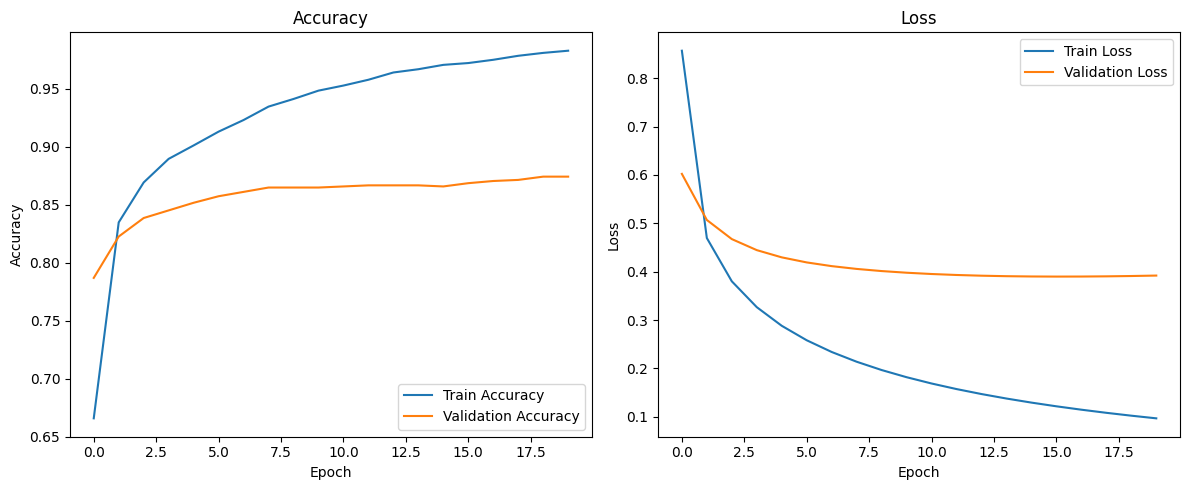


|------------------------------| Training DenseNet121 Baseline |--------------------------------|

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 66s 421ms/step - accuracy: 0.3778 - loss: 2.4071 - precision_4: 0.4008 - recall_4: 0.3211 - val_accuracy: 0.4967 - val_loss: 1.5505 - val_precision_4: 0.5465 - val_recall_4: 0.4197
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 113ms/step - accuracy: 0.5415 - loss: 1.3423 - precision_4: 0.5917 - recall_4: 0.4617 - val_accuracy: 0.5737 - val_loss: 1.2554 - val_precision_4: 0.6337 - val_recall_4: 0.4873
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - accuracy: 0.6056 - loss: 1.1043 - precision_4: 0.6577 - recall_4: 0.5268 - val_accuracy: 0.5991 - val_loss: 1.1447 - val_precision_4: 0.6564 - val_recall_4: 0.5221
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - accuracy: 0.6385 - loss: 0.9739 - precision_4: 0.6992 - recall_4: 0.5690 - val_accuracy: 0.6225 - val_loss: 1.0812 - val_precision_4: 0.6744 - val_recall_4: 0.5446
Epoch 5/20
100/1

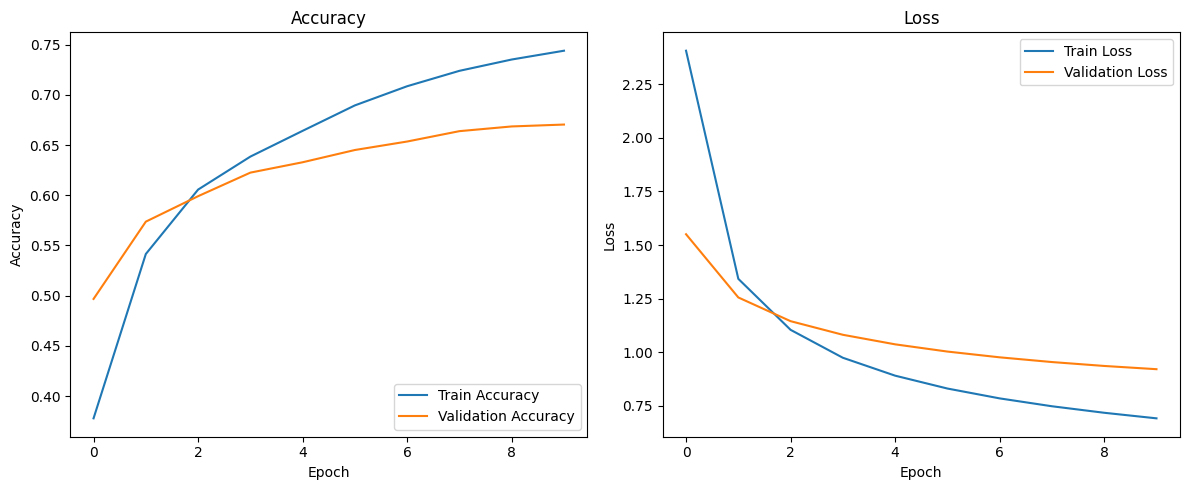


|------------------------------| Training Xception Baseline |--------------------------------|

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 81s 561ms/step - accuracy: 0.3358 - loss: 6.8530 - precision_5: 0.3353 - recall_5: 0.3252 - val_accuracy: 0.3624 - val_loss: 4.3204 - val_precision_5: 0.3670 - val_recall_5: 0.3484
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 205ms/step - accuracy: 0.4238 - loss: 3.4681 - precision_5: 0.4286 - recall_5: 0.4125 - val_accuracy: 0.4254 - val_loss: 3.2187 - val_precision_5: 0.4358 - val_recall_5: 0.4113
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 206ms/step - accuracy: 0.4751 - loss: 2.7387 - precision_5: 0.4864 - recall_5: 0.4595 - val_accuracy: 0.4563 - val_loss: 2.8611 - val_precision_5: 0.4667 - val_recall_5: 0.4413
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 188ms/step - accuracy: 0.5061 - loss: 2.3551 - precision_5: 0.5199 - recall_5: 0.4870 - val_accuracy: 0.4554 - val_loss: 2.8905 - val_precision_5

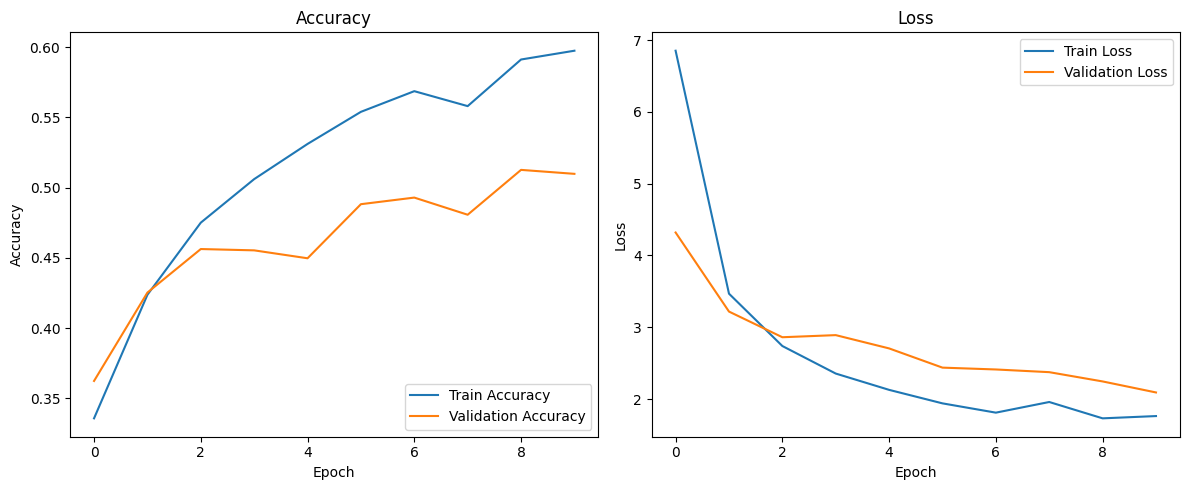

In [ ]:
#BASELINE MODELS

# Plot training history
def plot_history(history):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

# Paths
best_model_path = '/content/drive/My Drive/garbage dataset'
dataset_name = 'baseline_garbage'
train_dir = '/content/drive/My Drive/split garbage dataset/train'
val_dir = '/content/drive/My Drive/split garbage dataset/validation'
test_dir = '/content/drive/My Drive/split garbage dataset/test'

# Check for dataset directories
if not os.path.exists(train_dir):
    raise ValueError(f"Training directory does not exist: {train_dir}")
if not os.path.exists(val_dir):
    raise ValueError(f"Validation directory does not exist: {val_dir}")

img_height, img_width = 224, 224

# Prepare the datasets
train_data = image_dataset_from_directory(
    train_dir,
    image_size=(img_height, img_width),
    label_mode='categorical',
    batch_size=32
)
# train_data = train_data.map(process)
train_data = train_data.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

val_data = image_dataset_from_directory(
    val_dir,
    image_size=(img_height, img_width),
    label_mode='categorical',
    batch_size=32
)
# val_data = val_data.map(process)
val_data = val_data.cache().prefetch(buffer_size=tf.data.AUTOTUNE)


initial_learning_rate = 1e-3
model_callback = EarlyStopping(monitor='val_loss', patience=10, mode='min')






print('\n|------------------------------| Training MobileNetV3 Baseline |--------------------------------|\n')

model_checkpoint_fc = ModelCheckpoint(
    best_model_path + '/baseline-mobilenetv3-' + dataset_name + '-{epoch:02d}-{val_accuracy:.4f}.keras',
    save_best_only=True,
    save_weights_only=False,
    monitor='val_accuracy',
    mode='max'
)
# Build MobileNetV3 model
MobileNetV3_base_model = MobileNetV3Large(input_shape=(img_height, img_width, 3), include_top=False, weights='imagenet')
MobileNetV3_base_model.trainable = False

# Custom model layers
inputs = Input(shape=(img_height, img_width, 3))
x = MobileNetV3_base_model(inputs)
x = GlobalAveragePooling2D()(x)
outputs = Dense(units=5, activation='softmax')(x)

MobileNetV3_model = Model(inputs, outputs, name='Baseline_MobileNetV3')

# Compile the model
MobileNetV3_model.compile(
    optimizer=Adam(initial_learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)


MobileNetV3_history = MobileNetV3_model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    verbose=1,
    callbacks=[model_checkpoint_fc, model_callback]
)

plot_history(MobileNetV3_history)

print('\n|------------------------------| Training DenseNet121 Baseline |--------------------------------|\n')

model_checkpoint_fc = ModelCheckpoint(
    best_model_path + '/baseline-densenet121-' + dataset_name + '-{epoch:02d}-{val_accuracy:.4f}.keras',
    save_best_only=True,
    save_weights_only=False,
    monitor='val_accuracy',
    mode='max'
)

# Build DenseNet121 model
DenseNet_base_model = DenseNet121( input_shape=(img_height, img_width, 3), include_top=False, weights='imagenet')
DenseNet_base_model.trainable = False

# Custom layers
inputs = Input(shape=(img_height, img_width, 3))
x = DenseNet_base_model(inputs)
x = GlobalAveragePooling2D()(x)
outputs = Dense(units=5, activation='softmax')(x)

DenseNet_model = Model(inputs, outputs, name='Baseline_DenseNet121')

# Compile
DenseNet_model.compile(
    optimizer=Adam(initial_learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)

# Train
DenseNet_history = DenseNet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    verbose=1,
    callbacks=[model_checkpoint_fc, model_callback]
)

plot_history(DenseNet_history)

print('\n|------------------------------| Training Xception Baseline |--------------------------------|\n')
from tensorflow.keras.applications import Xception
model_checkpoint_fc = ModelCheckpoint(
    best_model_path + '/baseline-xception-' + dataset_name + '-{epoch:02d}-{val_accuracy:.4f}.keras',
    save_best_only=True,
    save_weights_only=False,
    monitor='val_accuracy',
    mode='max'
)

# Build Xception model
Xception_base_model = Xception( input_shape=(img_height, img_width, 3), include_top=False, weights='imagenet')
Xception_base_model.trainable = False

# Custom layers
inputs = Input(shape=(img_height, img_width, 3))
x = Xception_base_model(inputs)
x = GlobalAveragePooling2D()(x)
outputs = Dense(units=5, activation='softmax')(x)

Xception_model = Model(inputs, outputs, name='Baseline_Xception')

# Compile
Xception_model.compile(
    optimizer=Adam(initial_learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)

# Train
Xception_history = Xception_model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    verbose=1,
    callbacks=[model_checkpoint_fc, model_callback]
)

plot_history(Xception_history)

In [ ]:
def process(image, label):
    # image = tf.image.resize(image, (224, 224))
    image = tf.image.adjust_contrast(image, 1.2)
    # image = tf.image.per_image_standardization(image)
    return image, label

# Prepare the datasets
train_dir = '/content/drive/My Drive/augmented garbage dataset/augmented_train'
test_dir = '/content/drive/My Drive/augmented garbage dataset/augmented_test'
val_dir = '/content/drive/My Drive/augmented garbage dataset/augmented_validation'

img_height, img_width = 224, 224

train_data = image_dataset_from_directory(
    train_dir,
    image_size=(img_height, img_width),
    label_mode='categorical',
    batch_size=32
)
train_data = train_data.map(process)
train_data = train_data.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

test_data = image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    label_mode='categorical',
    batch_size=32
)
test_data = test_data.map(process)
test_data = test_data.cache().prefetch(buffer_size=tf.data.AUTOTUNE)


val_data = image_dataset_from_directory(
    val_dir,
    image_size=(img_height, img_width),
    label_mode='categorical',
    batch_size=32
)
val_data = val_data.map(process)
val_data = val_data.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 13577 files belonging to 5 classes.
Found 5042 files belonging to 5 classes.
Found 5021 files belonging to 5 classes.



|------------------------------| Training MobileNetV3 (Frozen) |--------------------------------|

Epoch 1/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 71s 139ms/step - accuracy: 0.4452 - loss: 1.3580 - precision_4: 0.5413 - recall_4: 0.2585 - val_accuracy: 0.6433 - val_loss: 0.9200 - val_precision_4: 0.7422 - val_recall_4: 0.4611 - learning_rate: 1.0000e-04
Epoch 2/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.7108 - loss: 0.7758 - precision_4: 0.8037 - recall_4: 0.5785 - val_accuracy: 0.7570 - val_loss: 0.6808 - val_precision_4: 0.8293 - val_recall_4: 0.6523 - learning_rate: 1.0000e-04
Epoch 3/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.7729 - loss: 0.6174 - precision_4: 0.8449 - recall_4: 0.6892 - val_accuracy: 0.8006 - val_loss: 0.5808 - val_precision_4: 0.8566 - val_recall_4: 0.7244 - learning_rate: 1.0000e-04
Epoch 4/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.8022 - loss: 0.5378 - precision_4: 0.8615 - recall_4: 0.7369 - val_accuracy: 0.8196 - v

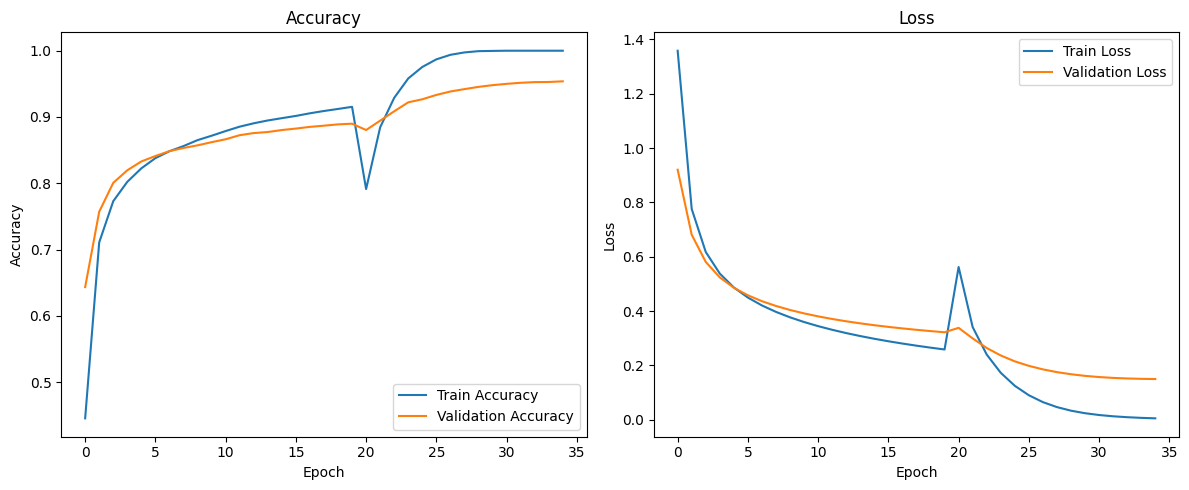

In [ ]:

#improved models with contrast - MobileNetV3

# Paths
best_model_path = '/content/drive/My Drive/garbage dataset'
dataset_name = 'garbage'

# Learning rates and callbacks
initial_learning_rate = 1e-4
fine_tune_learning_rate = 1e-5
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.1, patience=3, min_lr=1e-6, verbose=1
)
model_callback = EarlyStopping(monitor='val_loss', patience=10, mode='min')

# Check for dataset directories
if not os.path.exists(train_dir):
    raise ValueError(f"Training directory does not exist: {train_dir}")
if not os.path.exists(val_dir):
    raise ValueError(f"Validation directory does not exist: {val_dir}")

# Build MobileNetV3 model
MobileNetV3_base_model = MobileNetV3Large(input_shape=(img_height, img_width, 3), include_top=False, weights='imagenet')
MobileNetV3_base_model.trainable = False

# Custom model layers
inputs = Input(shape=(img_height, img_width, 3))
x = MobileNetV3_base_model(inputs)
x = GlobalAveragePooling2D()(x)
outputs = Dense(units=5, activation='softmax')(x)

MobileNetV3_model = Model(inputs, outputs, name='MobileNetV3')

# Compile the model
MobileNetV3_model.compile(
    optimizer=Adam(initial_learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)

# Train the model
print('\n|------------------------------| Training MobileNetV3 (Frozen) |--------------------------------|\n')
model_checkpoint_fc = ModelCheckpoint(
    best_model_path + '/improved-mobilenetv3-' + dataset_name + '-{epoch:02d}-{val_accuracy:.4f}.keras',
    save_best_only=True,
    save_weights_only=False,
    monitor='val_accuracy',
    mode='max'
)

# Initial training phase
MobileNetV3_history = MobileNetV3_model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    verbose=1,
    callbacks=[model_checkpoint_fc, model_callback, reduce_lr]
)

# Unfreeze some or all of the layers for fine-tuning
print('\n|------------------------------| Fine-Tuning MobileNetV3 |--------------------------------|\n')
MobileNetV3_base_model.trainable = True  # Unfreeze all layers for fine-tuning

# Re-compile with a lower learning rate for fine-tuning
MobileNetV3_model.compile(
    optimizer=Adam(fine_tune_learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)

# Fine-tuning phase
MobileNetV3_fine_tune_history = MobileNetV3_model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    verbose=1,
    callbacks=[model_checkpoint_fc, model_callback, reduce_lr]
)

# Merge history
for key in MobileNetV3_fine_tune_history.history.keys():
    if key in MobileNetV3_history.history:
        MobileNetV3_history.history[key].extend(MobileNetV3_fine_tune_history.history[key])
    else:
        MobileNetV3_history.history[key] = MobileNetV3_fine_tune_history.history[key]

# Plot training history
def plot_history(history):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

plot_history(MobileNetV3_history)



83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

|------------------------------| Training Xception (Frozen) |--------------------------------|

Epoch 1/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 138s 270ms/step - accuracy: 0.2617 - loss: 7.5565 - precision_6: 0.2633 - recall_6: 0.2533 - val_accuracy: 0.3045 - val_loss: 4.9144 - val_precision_6: 0.3083 - val_recall_6: 0.2924 - learning_rate: 1.0000e-04
Epoch 2/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 79s 185ms/step - accuracy: 0.3234 - loss: 4.3050 - precision_6: 0.3280 - recall_6: 0.3077 - val_accuracy: 0.3420 - val_loss: 3.7969 - val_precision_6: 0.3466 - val_recall_6: 0.3252 - learning_rate: 1.0000e-04
Epoch 3/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 79s 185ms/step - accuracy: 0.3599 - loss: 3.4762 - precision_6: 0.3669 - recall_6: 0.3404 - val_accuracy: 0.3661 - val_loss: 3.2562 - val_precision_6: 0.3748 - val_recall_6: 0.3473 - learning_rate: 1.0000e-04
Epoch 4/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 79s 185ms/step - accuracy: 0.3812 - loss: 3.0062 - precision_6: 

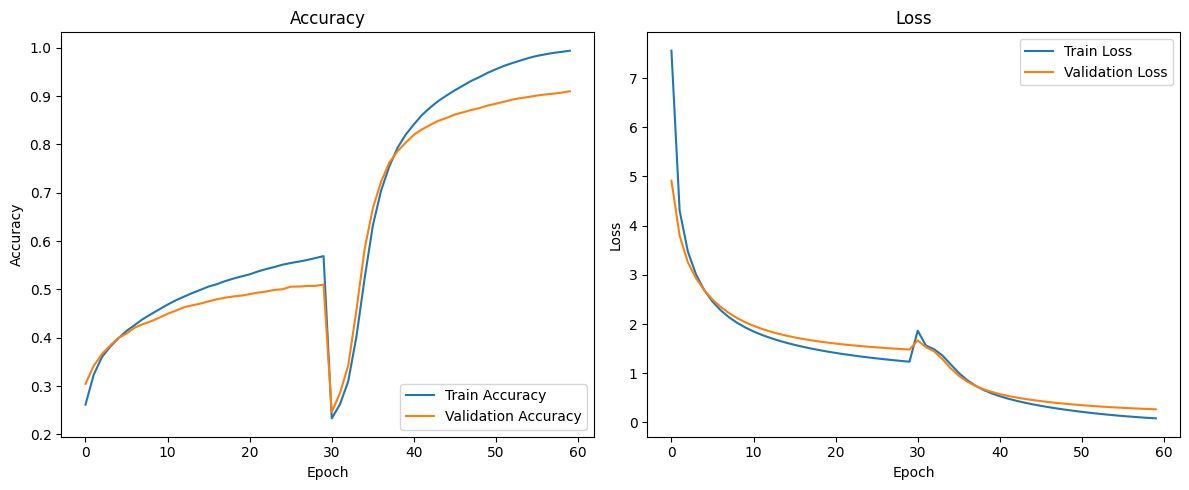

In [ ]:

#improved models with contrast - Xception

# Paths
best_model_path = '/content/drive/My Drive/garbage dataset'
dataset_name = 'garbage'


img_height, img_width = 224, 224
batch_size = 32

# Learning rates and callbacks
initial_learning_rate = 1e-4
fine_tune_learning_rate = 1e-6
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.1, patience=3, min_lr=1e-6, verbose=1
)
model_callback = EarlyStopping(monitor='val_loss', patience=10, mode='min')



# Build Xception model
Xception_base_model = tf.keras.applications.Xception(input_shape=(img_height, img_width, 3), include_top=False, weights='imagenet')
Xception_base_model.trainable = False  # Freeze the base model

# Custom model layers
inputs = Input(shape=(img_height, img_width, 3))
x = Xception_base_model(inputs)
x = GlobalAveragePooling2D()(x)
outputs = Dense(units=5, activation='softmax')(x)

Xception_model = Model(inputs, outputs, name='Xception')

# Compile the model
Xception_model.compile(
    optimizer=Adam(initial_learning_rate),
    loss=CategoricalCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)


# Train the model
print('\n|------------------------------| Training Xception (Frozen) |--------------------------------|\n')
model_checkpoint_fc = ModelCheckpoint(
    best_model_path + '/improved-xception-' + dataset_name + '-{epoch:02d}-{val_accuracy:.4f}.keras',
    save_best_only=True,
    save_weights_only=False,
    monitor='val_accuracy',  # Ensure this monitors validation accuracy
    mode='max'
)

# Initial training phase
Xception_history = Xception_model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    verbose=1,
    callbacks=[model_checkpoint_fc, model_callback, reduce_lr]
)

# Unfreeze some or all of the layers for fine-tuning
print('\n|------------------------------| Fine-Tuning Xception |--------------------------------|\n')
Xception_base_model.trainable = True  # Unfreeze all layers for fine-tuning

# Re-compile with a lower learning rate for fine-tuning
Xception_model.compile(
    optimizer=Adam(fine_tune_learning_rate),
    loss=CategoricalCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

# Fine-tuning phase
Xception_fine_tune_history = Xception_model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    verbose=1,
    callbacks=[model_checkpoint_fc, model_callback, reduce_lr]
)

# Merge history
for key in Xception_fine_tune_history.history.keys():
    if key in Xception_history.history:
        Xception_history.history[key].extend(Xception_fine_tune_history.history[key])
    else:
        Xception_history.history[key] = Xception_fine_tune_history.history[key]

# Plot training history
def plot_history(history):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

plot_history(Xception_history)



29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

|------------------------------| Training DenseNet121 (Frozen) |--------------------------------|

Epoch 1/40
425/425 ━━━━━━━━━━━━━━━━━━━━ 112s 197ms/step - accuracy: 0.2478 - loss: 3.5960 - precision: 0.2519 - recall: 0.2081 - val_accuracy: 0.3404 - val_loss: 2.2696 - val_precision: 0.3654 - val_recall: 0.2848 - learning_rate: 1.0000e-04
Epoch 2/40
425/425 ━━━━━━━━━━━━━━━━━━━━ 45s 107ms/step - accuracy: 0.4007 - loss: 1.9010 - precision: 0.4327 - recall: 0.3264 - val_accuracy: 0.4525 - val_loss: 1.6920 - val_precision: 0.4884 - val_recall: 0.3768 - learning_rate: 1.0000e-04
Epoch 3/40
425/425 ━━━━━━━━━━━━━━━━━━━━ 44s 103ms/step - accuracy: 0.4809 - loss: 1.5350 - precision: 0.5308 - recall: 0.3988 - val_accuracy: 0.5033 - val_loss: 1.4504 - val_precision: 0.5505 - val_recall: 0.4252 - learning_rate: 1.0000e-04
Epoch 4/40
425/425 ━━━━━━━━━━━━━━━━━━━━ 45s 105ms/step - accuracy: 0.5287 - loss: 1.3456 - precision: 0.5874 - recall: 0.4405

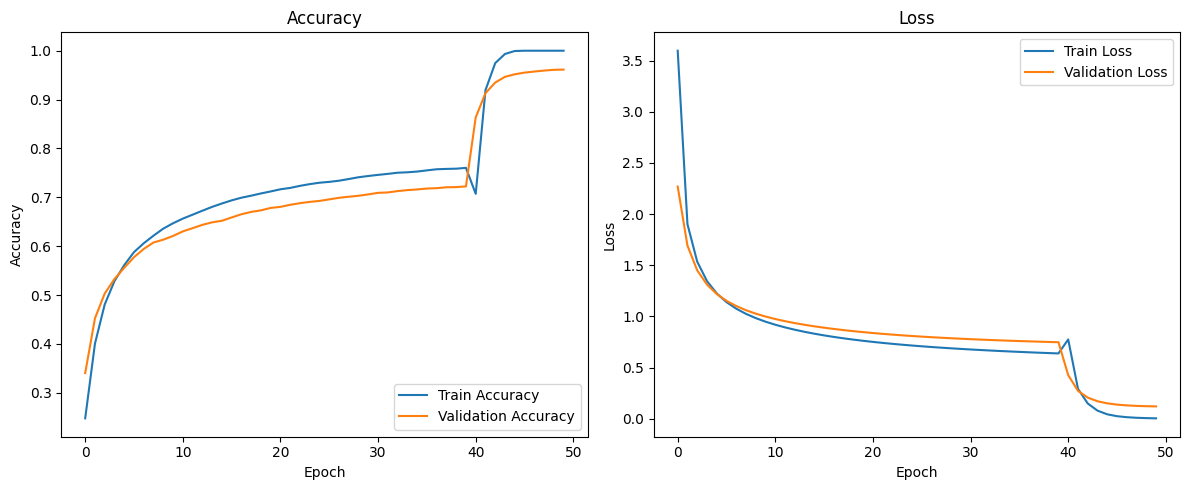

In [ ]:

#improved models with contrast - DenseNet

# Paths
best_model_path = '/content/drive/My Drive/garbage dataset'
dataset_name = 'garbage'

# Learning rates and callbacks
initial_learning_rate = 1e-4
fine_tune_learning_rate = 1e-5
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.1, patience=3, min_lr=1e-6, verbose=1
)
model_callback = EarlyStopping(monitor='val_loss', patience=10, mode='min')



# Build DenseNet121 base model
DenseNet_base_model = DenseNet121(input_shape=(img_height, img_width, 3), include_top=False, weights='imagenet')
DenseNet_base_model.trainable = False

# Custom model layers
inputs = Input(shape=(img_height, img_width, 3))
x = DenseNet_base_model(inputs)
x = GlobalAveragePooling2D()(x)
outputs = Dense(units=5, activation='softmax')(x)

DenseNet_model = Model(inputs, outputs, name='DenseNet121')

# Compile the model with detailed metrics
DenseNet_model.compile(
    optimizer=Adam(initial_learning_rate),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)



# Train the model
print('\n|------------------------------| Training DenseNet121 (Frozen) |--------------------------------|\n')
model_checkpoint_fc = ModelCheckpoint(
    best_model_path + '/improved-densenet121-' + dataset_name + '-{epoch:02d}-{val_accuracy:.4f}.keras',
    save_best_only=True,
    save_weights_only=False,
    monitor='val_accuracy',
    mode='max'
)

# Initial training phase
DenseNet_history = DenseNet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=40,
    verbose=1,
    callbacks=[model_checkpoint_fc, model_callback, reduce_lr]
)

# Unfreeze some or all of the layers for fine-tuning
print('\n|------------------------------| Fine-Tuning DenseNet121 |--------------------------------|\n')
DenseNet_base_model.trainable = True  # Unfreeze all layers for fine-tuning

# Re-compile with a lower learning rate for fine-tuning
DenseNet_model.compile(
    optimizer=Adam(fine_tune_learning_rate),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# Fine-tuning phase
DenseNet_fine_tune_history = DenseNet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    verbose=1,
    callbacks=[model_checkpoint_fc, model_callback, reduce_lr]
)

# Merge history
for key in DenseNet_fine_tune_history.history.keys():
    if key in DenseNet_history.history:
        DenseNet_history.history[key].extend(DenseNet_fine_tune_history.history[key])
    else:
        DenseNet_history.history[key] = DenseNet_fine_tune_history.history[key]

# Plot training history
def plot_history(history):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

plot_history(DenseNet_history)




Found 13577 files belonging to 5 classes.
Found 5042 files belonging to 5 classes.
Found 5021 files belonging to 5 classes.

|------------------------------| Training Xception (Frozen) |--------------------------------|

Epoch 1/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 101s 218ms/step - accuracy: 0.2694 - loss: 9.4950 - precision_9: 0.2698 - recall_9: 0.2627 - val_accuracy: 0.3125 - val_loss: 5.0413 - val_precision_9: 0.3164 - val_recall_9: 0.3029 - learning_rate: 1.0000e-04
Epoch 2/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 79s 187ms/step - accuracy: 0.3184 - loss: 4.4917 - precision_9: 0.3215 - recall_9: 0.3040 - val_accuracy: 0.3481 - val_loss: 3.8786 - val_precision_9: 0.3584 - val_recall_9: 0.3336 - learning_rate: 1.0000e-04
Epoch 3/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 79s 185ms/step - accuracy: 0.3507 - loss: 3.6070 - precision_9: 0.3581 - recall_9: 0.3336 - val_accuracy: 0.3696 - val_loss: 3.3187 - val_precision_9: 0.3780 - val_recall_9: 0.3485 - learning_rate: 1.0000e-04
Epoch 4/30
425/425 ━━━━━━━━━━━━

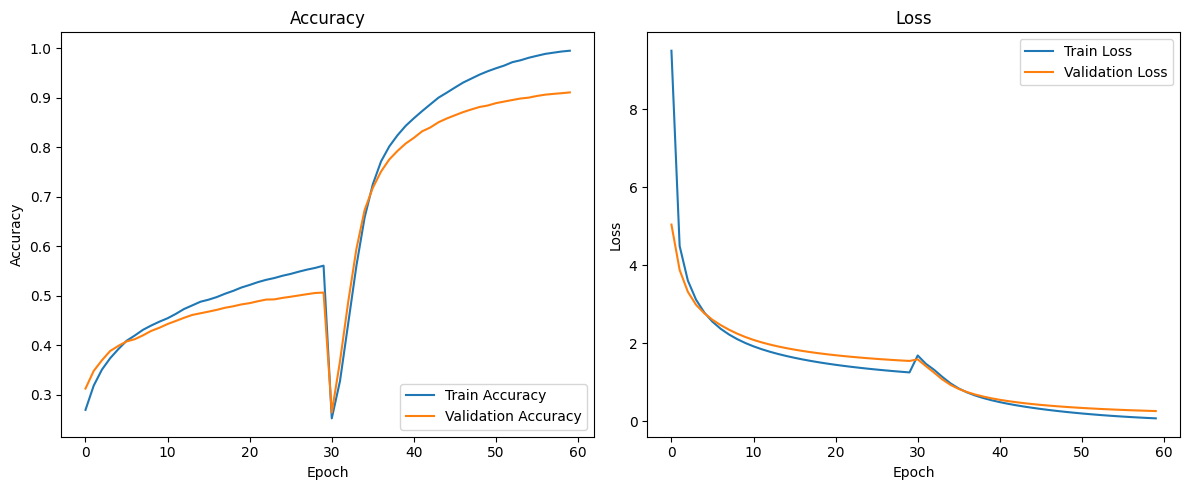

In [ ]:

#improved models without contrast - Xception


# Prepare the datasets
train_dir = '/content/drive/My Drive/augmented garbage dataset/augmented_train'
test_dir = '/content/drive/My Drive/augmented garbage dataset/augmented_test'
val_dir = '/content/drive/My Drive/augmented garbage dataset/augmented_validation'

img_height, img_width = 224, 224

train_data_no_process = image_dataset_from_directory(
    train_dir,
    image_size=(img_height, img_width),
    label_mode='categorical',
    batch_size=32
)
train_data_no_process = train_data_no_process.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_data_no_process  = image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    label_mode='categorical',
    batch_size=32
)
test_data_no_process = test_data_no_process.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_data_no_process  = image_dataset_from_directory(
    val_dir,
    image_size=(img_height, img_width),
    label_mode='categorical',
    batch_size=32
)
val_data_no_process = val_data_no_process.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

#############################3#################################
# Paths
best_model_path = '/content/drive/My Drive/garbage dataset'
dataset_name = 'garbage'


img_height, img_width = 224, 224
batch_size = 32

# Learning rates and callbacks
initial_learning_rate = 1e-4
fine_tune_learning_rate = 1e-6
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.1, patience=3, min_lr=1e-6, verbose=1
)
model_callback = EarlyStopping(monitor='val_loss', patience=10, mode='min')



# Build Xception model
Xception_base_model = tf.keras.applications.Xception(input_shape=(img_height, img_width, 3), include_top=False, weights='imagenet')
Xception_base_model.trainable = False  # Freeze the base model

# Custom model layers
inputs = Input(shape=(img_height, img_width, 3))
x = Xception_base_model(inputs)
x = GlobalAveragePooling2D()(x)
outputs = Dense(units=5, activation='softmax')(x)

Xception_model = Model(inputs, outputs, name='Xception')

# Compile the model
Xception_model.compile(
    optimizer=Adam(initial_learning_rate),
    loss=CategoricalCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)


# Train the model
print('\n|------------------------------| Training Xception (Frozen) |--------------------------------|\n')
model_checkpoint_fc = ModelCheckpoint(
    best_model_path + '/normal-xception-' + dataset_name + '-{epoch:02d}-{val_accuracy:.4f}.keras',
    save_best_only=True,
    save_weights_only=False,
    monitor='val_accuracy',  # Ensure this monitors validation accuracy
    mode='max'
)

# Initial training phase
Xception_history = Xception_model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    verbose=1,
    callbacks=[model_checkpoint_fc, model_callback, reduce_lr]
)

# Unfreeze some or all of the layers for fine-tuning
print('\n|------------------------------| Fine-Tuning Xception |--------------------------------|\n')
Xception_base_model.trainable = True  # Unfreeze all layers for fine-tuning

# Re-compile with a lower learning rate for fine-tuning
Xception_model.compile(
    optimizer=Adam(fine_tune_learning_rate),
    loss=CategoricalCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

# Fine-tuning phase
Xception_fine_tune_history = Xception_model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    verbose=1,
    callbacks=[model_checkpoint_fc, model_callback, reduce_lr]
)

# Merge history
for key in Xception_fine_tune_history.history.keys():
    if key in Xception_history.history:
        Xception_history.history[key].extend(Xception_fine_tune_history.history[key])
    else:
        Xception_history.history[key] = Xception_fine_tune_history.history[key]

# Plot training history
def plot_history(history):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

plot_history(Xception_history)



In [ ]:

# Test all the models' versions on test dataset

test_dir = '/content/drive/My Drive/augmented garbage dataset/augmented_test'
test_data_no_process  = image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    label_mode='categorical',
    batch_size=32
)
test_data_no_process = test_data_no_process.cache().prefetch(buffer_size=tf.data.AUTOTUNE)


#calling models
baseline_densenet121 = load_model('/content/drive/My Drive/garbage dataset/baseline-densenet121-baseline_garbage-10-0.6723.keras')
baseline_mobilenetv3 = load_model('/content/drive/My Drive/garbage dataset/baseline-mobilenetv3-baseline_garbage-19-0.8742.keras')
baseline_xception = load_model('/content/drive/My Drive/garbage dataset/baseline-xception-baseline_garbage-09-0.5127.keras')


normal_densenet121 = load_model('/content/drive/My Drive/garbage dataset/normal-densenet121-garbage-10-0.9249.keras')
normal_mobilenetv3 = load_model('/content/drive/My Drive/garbage dataset/normal-mobilenetv3-garbage-15-0.9080.keras')
normal_xception = load_model('/content/drive/My Drive/garbage dataset/normal-xception-garbage-30-0.9110.keras')


improved_densenet121 = load_model('/content/drive/My Drive/garbage dataset/improved-densenet121-garbage-10-0.9614.keras')
improved_mobilenetv3 = load_model('/content/drive/My Drive/garbage dataset/improved-mobilenetv3-garbage-15-0.9538.keras')
improved_xception = load_model('/content/drive/My Drive/garbage dataset/improved-xception-garbage-30-0.9098.keras')


print("mobilenetv3 Model Results:")
baseline_mobilenetv3_results = baseline_mobilenetv3.evaluate(test_data_no_process)
print("Results with baseline-mobilenetv3", baseline_mobilenetv3_results)

normal_mobilenetv3_results = normal_mobilenetv3.evaluate(test_data_no_process)
print("Results with normal-mobilenetv3:", normal_mobilenetv3_results)

improved_mobilenetv3_results = improved_mobilenetv3.evaluate(test_data_no_process)
print("Results with improved-mobilenetv3:", improved_mobilenetv3_results)


print("densenet121 Model Results:")
baseline_densenet121_results = baseline_densenet121.evaluate(test_data_no_process)
print("Results with baseline-densenet121", baseline_densenet121_results)

normal_densenet121_results = normal_densenet121.evaluate(test_data_no_process)
print("Results with normal-densenet121:", normal_densenet121_results)

improved_densenet121_results = improved_densenet121.evaluate(test_data_no_process)
print("Results with improved-densenet121:", improved_densenet121_results)


print("xception Model Results:")
baseline_xception_results = baseline_xception.evaluate(test_data_no_process)
print("Results with baseline-xception", baseline_xception_results)

normal_xception_results = normal_xception.evaluate(test_data_no_process)
print("Results with normal-xception:", normal_xception_results)

improved_xception_results = improved_xception.evaluate(test_data_no_process)
print("Results with improved-xception:", improved_xception_results)




Found 5042 files belonging to 5 classes.
mobilenetv3 Model Results:
158/158 ━━━━━━━━━━━━━━━━━━━━ 23s 99ms/step - accuracy: 0.8138 - loss: 0.5299 - precision_3: 0.8329 - recall_3: 0.7999
Results with baseline-mobilenetv3 [0.5299170017242432, 0.8137643933296204, 0.832920253276825, 0.7998809814453125]
158/158 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - accuracy: 0.9528 - loss: 0.1511 - precision_13: 0.9550 - recall_13: 0.9512
Results with normal-mobilenetv3: [0.15109404921531677, 0.9527965188026428, 0.9549980163574219, 0.9512098431587219]
158/158 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - accuracy: 0.8846 - loss: 0.3774 - precision_5: 0.8888 - recall_5: 0.8802
Results with improved-mobilenetv3: [0.3774125576019287, 0.8845696449279785, 0.88884437084198, 0.880206286907196]
densenet121 Model Results:
158/158 ━━━━━━━━━━━━━━━━━━━━ 36s 128ms/step - accuracy: 0.6180 - loss: 1.1414 - precision_2: 0.6573 - recall_2: 0.5631
Results with baseline-densenet121 [1.1414088010787964, 0.6180087327957153, 0.65732806921

In [ ]:

# Load the external TrashNet dataset and evaluate the improved models on unseen data to test generalization performance.

test_dir = '/content/drive/My Drive/TrashNet/dataset-resized'
test_data_no_process  = image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    label_mode='categorical',
    batch_size=32
)

test_data_no_process = test_data_no_process.cache().prefetch(buffer_size=tf.data.AUTOTUNE)


normal_densenet121 = load_model('/content/drive/My Drive/garbage dataset/normal-densenet121-garbage-10-0.9249.keras')
normal_mobilenetv3 = load_model('/content/drive/My Drive/garbage dataset/normal-mobilenetv3-garbage-15-0.9080.keras')
normal_xception = load_model('/content/drive/My Drive/garbage dataset/normal-xception-garbage-30-0.9110.keras')



normal_densenet121_results = normal_densenet121.evaluate(test_data_no_process)
print("Results with normal-densenet121:", normal_densenet121_results)

normal_mobilenetv3_results = normal_mobilenetv3.evaluate(test_data_no_process)
print("Results with normal-mobilenetv3:", normal_mobilenetv3_results)

normal_xception_results = normal_xception.evaluate(test_data_no_process)
print("Results with normal-xception:", normal_xception_results)


Found 2390 files belonging to 5 classes.
75/75 ━━━━━━━━━━━━━━━━━━━━ 30s 190ms/step - accuracy: 0.9623 - loss: 0.1263 - precision: 0.9639 - recall: 0.9594
Results with normal-densenet121: [0.12628182768821716, 0.9623430967330933, 0.9638503789901733, 0.9594142436981201]
75/75 ━━━━━━━━━━━━━━━━━━━━ 20s 171ms/step - accuracy: 0.9565 - loss: 0.1556 - precision_13: 0.9581 - recall_13: 0.9565
Results with normal-mobilenetv3: [0.1555771678686142, 0.9564853310585022, 0.9580888748168945, 0.9564853310585022]
75/75 ━━━━━━━━━━━━━━━━━━━━ 32s 354ms/step - accuracy: 0.9310 - loss: 0.2323 - precision_10: 0.9433 - recall_10: 0.9180
Results with normal-xception: [0.23232688009738922, 0.930962324142456, 0.9432502388954163, 0.9179916381835938]


Found 5042 files belonging to 5 classes.
Class names: ['Cardboard', 'Glass', 'Metal', 'Paper', 'Plastic']
113/113 ━━━━━━━━━━━━━━━━━━━━ 44s 218ms/step


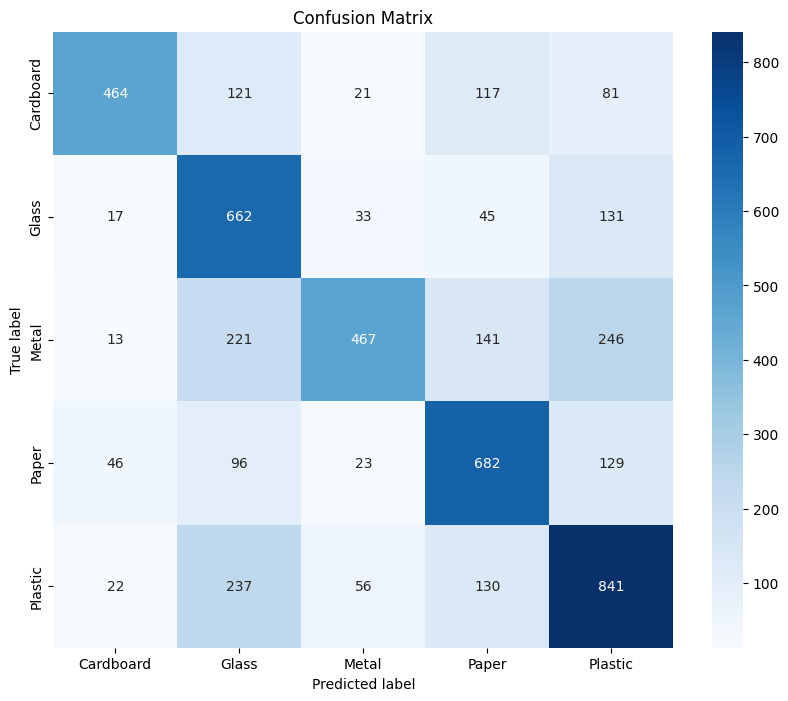

In [10]:


## confusion matrix

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

test_dir = '/content/drive/My Drive/augmented garbage dataset/augmented_test'
test_data = image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='categorical',
    shuffle=False
)

baseline_densenet121 = load_model('/content/drive/My Drive/garbage dataset/baseline-densenet121-baseline_garbage-10-0.6723.keras')
baseline_mobilenetv3 = load_model('/content/drive/My Drive/garbage dataset/baseline-mobilenetv3-baseline_garbage-19-0.8742.keras')
baseline_xception = load_model('/content/drive/My Drive/garbage dataset/baseline-xception-baseline_garbage-09-0.5127.keras')


normal_densenet121 = load_model('/content/drive/My Drive/garbage dataset/normal-densenet121-garbage-10-0.9249.keras')
normal_mobilenetv3 = load_model('/content/drive/My Drive/garbage dataset/normal-mobilenetv3-garbage-15-0.9080.keras')
normal_xception = load_model('/content/drive/My Drive/garbage dataset/normal-xception-garbage-30-0.9110.keras')


improved_densenet121 = load_model('/content/drive/My Drive/garbage dataset/improved-densenet121-garbage-10-0.9614.keras')
improved_mobilenetv3 = load_model('/content/drive/My Drive/garbage dataset/improved-mobilenetv3-garbage-15-0.9538.keras')
improved_xception = load_model('/content/drive/My Drive/garbage dataset/improved-xception-garbage-30-0.9098.keras')
model = baseline_densenet121

models = {
    "Baseline DenseNet121": baseline_densenet121,
    "Baseline MobileNetV3": baseline_mobilenetv3,
    "Baseline Xception": baseline_xception,

    "Normal DenseNet121": normal_densenet121,
    "Normal MobileNetV3": normal_mobilenetv3,
    "Normal Xception": normal_xception,

    "Improved DenseNet121": improved_densenet121,
    "Improved MobileNetV3": improved_mobilenetv3,
    "Improved Xception": improved_xception
}



# Retrieve class names
class_names = test_data.class_names
print("Class names:", class_names)



y_true = np.concatenate([y for _, y in test_data], axis=0)
y_true_classes = np.argmax(y_true, axis=1)

def plot_confusion_matrix(cm, class_names, title, save_path):

    fig, ax = plt.subplots(figsize=(3,3))

    sns.heatmap(
        cm,
        annot=False,
        cmap='Blues',
        cbar=False,
        xticklabels=False,
        yticklabels=False,
        square=True
    )

    plt.tight_layout(pad=0)

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches='tight',
        pad_inches=0
    )

    plt.close()

# Make predictions
y_true = np.concatenate([y for _, y in test_data], axis=0)  # True labels
y_pred = model.predict(test_data)  # Predicted probabilities
y_pred_classes = np.argmax(y_pred, axis=1)  # Predicted class indices
y_true_classes = np.argmax(y_true, axis=1)  # True class indices

# Compute the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Function to plot confusion matrix
def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title('Confusion Matrix')
    plt.show()

# Plot the confusion matrix
plot_confusion_matrix(cm, class_names)



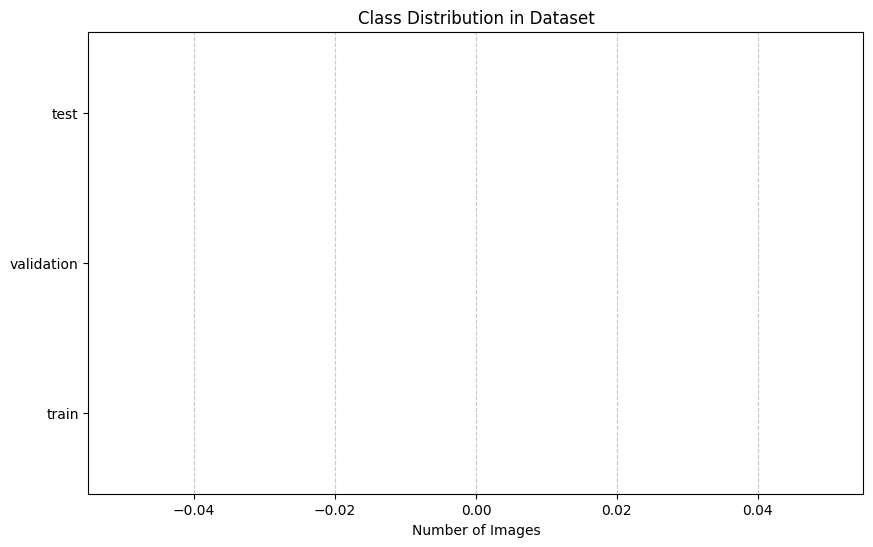

In [32]:

def show_class_distribution(data_dir):
    class_counts = {}

    # Iterate through each class directory
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)

        # Check if it is a directory
        if os.path.isdir(class_path):
            # Count the number of image files in the class directory
            num_files = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif'))])
            class_counts[class_name] = num_files

    # Sort the class counts for better visualization
    class_names = list(class_counts.keys())
    counts = list(class_counts.values())

    # Plotting the class distribution
    plt.figure(figsize=(10, 6))
    plt.barh(class_names, counts, color='#a0aec0')  # Professional deep blue color
    plt.xlabel('Number of Images')
    plt.title('Class Distribution in Dataset')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

# Call the function with the path to your dataset
dataset_path =  '/content/drive/My Drive/split garbage dataset/'

show_class_distribution(dataset_path)

# show_class_distribution(augmented_dataset_dir)


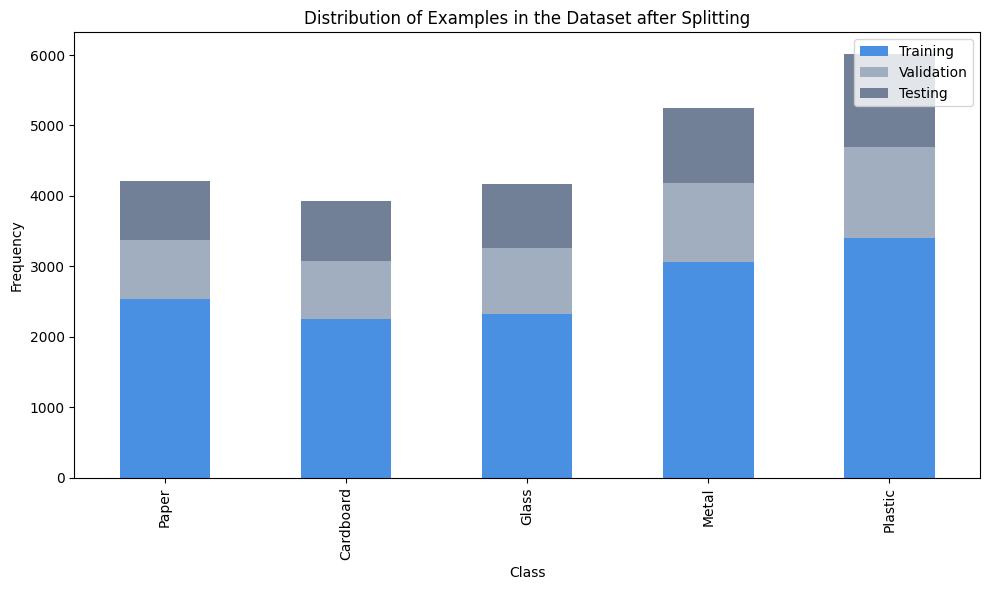

In [ ]:


# Define the paths to each dataset split
train_dir = '/content/drive/My Drive/garbage dataset/augmented_train'
test_dir = '/content/drive/My Drive/garbage dataset/augmented_test'
validate_dir = '/content/drive/My Drive/garbage dataset/augmented_validation'

# Define the classes
classes = ['Paper', 'Cardboard', 'Glass', 'Metal', 'Plastic']

# Function to count images in each class for each split
def count_images(directory, classes):
    counts = {}
    for cls in classes:
        class_dir = os.path.join(directory, cls)
        counts[cls] = len(os.listdir(class_dir)) if os.path.exists(class_dir) else 0
    return counts

# Get counts for each split
train_counts = count_images(train_dir, classes)
validate_counts = count_images(validate_dir, classes)
test_counts = count_images(test_dir, classes)

# Create a DataFrame for easier plotting
data = {
    'Training': train_counts,
    'Validation': validate_counts,
    'Testing': test_counts
}
df = pd.DataFrame(data, index=classes)

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Create a stacked bar plot with lighter professional colors
df.plot(kind='bar', stacked=True, ax=ax, color=['#4a90e2', '#a0aec0', '#718096'])  # Light Blue, Light Gray, Medium Gray

# Labeling
ax.set_ylabel('Frequency')
ax.set_xlabel('Class')
ax.set_title('Distribution of Examples in the Dataset after Splitting')

# Customize legend
ax.legend(title='', labels=['Training', 'Validation', 'Testing'], loc='upper right')

plt.tight_layout()
plt.show()


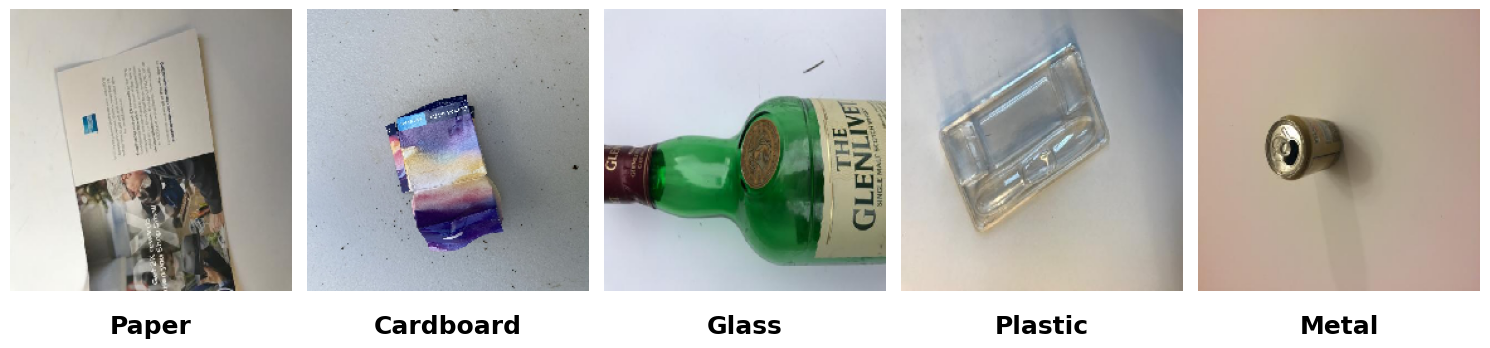

In [11]:
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing import image
import numpy as np

dataset_path =  '/content/drive/My Drive/split garbage dataset/train'

classes = ['Paper', 'Cardboard', 'Glass', 'Plastic', 'Metal']

fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for i, class_name in enumerate(classes):

    class_path = os.path.join(dataset_path, class_name)
    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)

    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img).astype("uint8")

    axes[i].imshow(img_array)

    axes[i].text(
        0.5, -0.08, class_name,
        transform=axes[i].transAxes,
        ha='center',
        va='top',
        fontsize=18,
        fontweight='bold'    )
    axes[i].axis('off')

plt.tight_layout()
plt.show()

def create_model():
    base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=True, weights=None, classes=9)  # 9 classes
    model = models.Sequential()
    model.add(base_model)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model